# Verification — `MIL_CREDA` against `research-concept-r17.md`

Executed report, not the source of truth. Every mathematical claim lives as a
test under `tests/`; this page runs them and shows the evidence. Existence of
this file proves nothing — `verify` reads whether its cells actually ran.

The implementation computes with PyTorch. That is a change of backend, not of
method: the equations are the same equations, and this report re-establishes them
over the same 200 sweep configurations as the numpy pass did, so a difference
would be attributable to the backend and to nothing else.

Re-run headlessly from the repository root:

```
.venv/bin/jupyter nbconvert --to notebook --execute --inplace \
  MIL-CREDA/Notebooks/verification.ipynb
```

In [1]:
import ast
import sys
from pathlib import Path

import torch

ROOT = Path.cwd().parents[1]  # <repo>/MIL-CREDA/Notebooks -> <repo>
sys.path.insert(0, str(ROOT / "src"))
print(f"torch {torch.__version__}   default dtype for this package: float64")

# Which revision each module was written against, read statically.
for file in sorted((ROOT / "src" / "MIL_CREDA").rglob("*.py")):
    if file.name == "__init__.py":
        continue
    for node in ast.parse(file.read_text()).body:
        if any(getattr(t, "id", None) == "__provenance__" for t in getattr(node, "targets", [])):
            p = ast.literal_eval(node.value)
            print(f"{file.name:<18} {p['revision']:<26} eqs {','.join(p['equations'])}")

torch 2.13.0   default dtype for this package: float64
attention.py       research-concept-r17.md    eqs 14,15,16
bag_kernel.py      research-concept-r17.md    eqs 20,21
conditional.py     research-concept-r17.md    eqs 23,25,26,27
confidence.py      research-concept-r17.md    eqs 22,24
global_term.py     research-concept-r17.md    eqs 32,33,34,35,36,37
kernels.py         research-concept-r17.md    eqs 2,19
local_term.py      research-concept-r17.md    eqs 28,29,30,31,38
objective.py       research-concept-r17.md    eqs 18,39
renyi.py           research-concept-r17.md    eqs 7,8,9,10,11,12


## Levels 1, 2, 4 and 5 — the suite

A red cell here means the implementation does not match what the proposal
claims. Do not edit the assertion to make it pass.

In [2]:
import pytest

code = pytest.main(["-q", str(ROOT / "tests"), "--rootdir", str(ROOT)])
assert code == 0, f"test suite failed (pytest exit code {code})"

.

.

.

.

.

...

.

.

.

                                                        [100%]

=============================== warnings summary ===============================
../../.venv/lib/python3.12/site-packages/tqdm/auto.py:21
  /Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
    from .autonotebook import tqdm as notebook_tqdm

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
161 passed, 1 warning in 4.91s


## Level 3 — synthetic evidence

Deterministic, fixed seed, ground truth known by construction. State the
expected behaviour before looking at the output.

target bags measured: 905   max d_j^2 = 1.999267
adopted normalizer /2 -> max l_loc,j = 0.999633   (uses the full range)
retired normalizer /4 -> max l_loc,j = 0.499817   (upper half unusable)


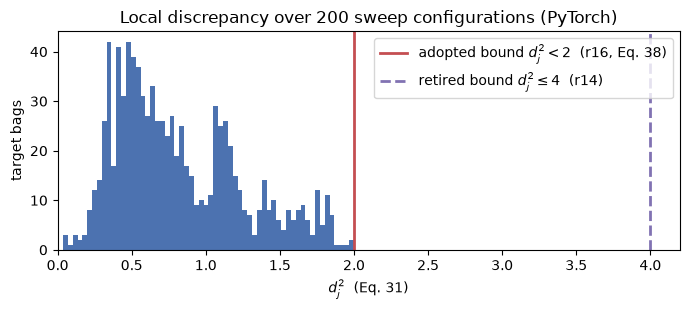

In [3]:
# Level 3 evidence: the bound r16 adopted, drawn from the same sweep the tests use.
import sys
sys.path.insert(0, str(ROOT / "tests"))
import matplotlib.pyplot as plt
from sweep import sweep

distances = torch.cat([c["squared_distances"] for c in sweep() if c["squared_distances"].numel()])
largest = float(distances.max())
print(f"target bags measured: {distances.numel()}   max d_j^2 = {largest:.6f}")
print(f"adopted normalizer /2 -> max l_loc,j = {largest / 2:.6f}   (uses the full range)")
print(f"retired normalizer /4 -> max l_loc,j = {largest / 4:.6f}   (upper half unusable)")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(distances.numpy(), bins=60, color="#4c72b0")
ax.axvline(2.0, color="#c44e52", lw=2, label="adopted bound $d_j^2 < 2$  (r16, Eq. 38)")
ax.axvline(4.0, color="#8172b2", lw=2, ls="--", label="retired bound $d_j^2 \\leq 4$  (r14)")
ax.set_xlim(0, 4.2)
ax.set_xlabel("$d_j^2$  (Eq. 31)")
ax.set_ylabel("target bags")
ax.set_title("Local discrepancy over 200 sweep configurations (PyTorch)")
ax.legend()
fig.tight_layout()
fig.savefig(ROOT / "MIL-CREDA" / "Results" / "local_distance_bound.pdf")
plt.show()

In [4]:
# El sello: contra qué código corrió este informe. Sin él, un informe viejo y uno
# recién generado se ven idénticos y el viejo se sigue creyendo.
from MIL_CREDA_Benchmark import report_digest

print(report_digest.stamp())

SOURCES-SHA256 11c70a7f7ed1eb3ec000a735153474fbc326f0483a679c0621b129be251514d5
